# BITS on NuPlan Mini: Inference Demo

This notebook is the current local BITS demo for the NuPlan mini reproduction path. It loads a saved local planner checkpoint, combines it with the official TBSIM/BITS predictor checkpoint for the low-level policy and future predictor, and runs inference plus a small saved open-loop summary.

The notebook path is inference-only; it does not train a model:

1. load the saved final `BitsRunConfig`;
2. load the saved planner checkpoint;
3. combine it with the official predictor checkpoint;
4. verify one real sample from each split;
5. run a single-sample forward pass and visualize the goal heatmap/trajectory;
6. read the saved open-loop evaluation result.

Training and cache rebuilding are handled outside this notebook by `scripts/run_bits_planner_cached_train.py`. Longer evaluation can be rerun by setting `RUN_EVALUATION = True` in the setup cell.

## 1. Setup

The generated checkpoints stay outside the repository under `D:/tactics/checkpoints/bits`. The notebook kernel should be `tactics2d`, which points at `D:/envs/tactics2d/python.exe` on this machine and uses Python 3.9.25. Install the optional torch dependencies with `pip install -e .[bits]` before running the inference cells.

In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np


def find_repo_root(start):
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tactics2d" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Cannot find the Tactics2D repository root.")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

warnings.filterwarnings("ignore", message="Trying to unpickle estimator SVC.*")

from tactics2d.behavior.bits import BitsPlan
from tactics2d.behavior.bits.model import BitsAgentPrediction, BitsPlanScorer
from tactics2d.behavior.bits.training import (
    build_nuplan_bits_dataset,
    load_bits_inference_model,
    load_bits_run_config,
    run_nuplan_bits_open_loop_protocol,
    run_nuplan_bits_rolling_protocol,
)
from tactics2d.behavior.bits.torch_model import bits_batch_to_torch
from tactics2d.dataset_parser import NuPlanParser

try:
    import torch
except ImportError:
    torch = None

CHECKPOINT_ROOT = Path("D:/tactics/checkpoints/bits")
RUN_ROOT = CHECKPOINT_ROOT / "nuplan_mini_all_unet_v1"
TRAIN_RUN_DIR = RUN_ROOT / "train_valid57_4sample_clean_decoder_e120"
PLANNER_DIR = TRAIN_RUN_DIR / "planner_frozen_predictor"
RUN_CONFIG_PATH = PLANNER_DIR / "bits_run_config.json"
PLANNER_CHECKPOINT = PLANNER_DIR / "bits_planner_best_val.pt"
PREDICTOR_CHECKPOINT = (
    CHECKPOINT_ROOT
    / "nusc_dynUnicycle_gl0_yrl0_tfTrue_4130553"
    / "run0"
    / "checkpoints"
    / "iter94000_ep6_valLoss0.06.ckpt"
)
OPEN_LOOP_DIR = PLANNER_DIR
ROLLING_DIR = TRAIN_RUN_DIR / "rolling_clean_decoder_eval"
OPEN_LOOP_RESULT_PATH = OPEN_LOOP_DIR / "bits_planner_cached_train_result.json"
ROLLING_RESULT_PATH = ROLLING_DIR / "bits_rolling_protocol_result.json"

RUN_EVALUATION = False
DEMO_SPLIT_NAME = "train"
DEMO_LOG_INDEX = 2
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

run_config = load_bits_run_config(RUN_CONFIG_PATH)
split_sizes = {
    "train": len(run_config.split.train),
    "val": len(run_config.split.val),
    "test": len(run_config.split.test),
}

print("repo_root:", repo_root)
print("device:", DEVICE)
print("run config exists:", RUN_CONFIG_PATH.exists())
print("planner checkpoint exists:", PLANNER_CHECKPOINT.exists())
print("official predictor exists:", PREDICTOR_CHECKPOINT.exists())
print("split sizes:", split_sizes)

repo_root: D:\tactics\tactics2d
device: cuda
run config exists: True
planner checkpoint exists: True
official predictor exists: True
split sizes: {'train': 57, 'val': 8, 'test': 8}


## 2. Load Saved Weights

This notebook only loads saved artifacts. The selected planner checkpoint comes from the final local mini run: 57 usable mini logs, up to four samples per log, 120 cached epochs, and the official predictor/shared encoder kept frozen during the saved training run. The trained planner is loaded with `load_bits_inference_model(tactics2d_planner_checkpoint=..., predictor_checkpoint=...)`, then used as a normal torch inference model in the multi-sample cell below. The training entry point is `scripts/run_bits_planner_cached_train.py`.

In [2]:
required_paths = {
    "run_config": RUN_CONFIG_PATH,
    "planner_checkpoint": PLANNER_CHECKPOINT,
    "predictor_checkpoint": PREDICTOR_CHECKPOINT,
}
for name, path in required_paths.items():
    print(f"{name}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

print("schedule:", run_config.schedule)
print("config future/history:", run_config.config.future_steps, run_config.config.history_steps)
if torch is not None:
    checkpoint_metadata = torch.load(PLANNER_CHECKPOINT, map_location="cpu").get("metadata", {})
    print("selected planner epoch:", checkpoint_metadata.get("epoch", "unknown"))
else:
    print("selected planner epoch: unknown")

run_config: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\planner_frozen_predictor\bits_run_config.json
planner_checkpoint: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\planner_frozen_predictor\bits_planner_best_val.pt
predictor_checkpoint: D:\tactics\checkpoints\bits\nusc_dynUnicycle_gl0_yrl0_tfTrue_4130553\run0\checkpoints\iter94000_ep6_valLoss0.06.ckpt
schedule: BitsTrainingSchedule(epochs=120, batch_size=4, learning_rate=0.0001, weight_decay=0.0, hidden_dim=128, model_arch='resnet18', context_size=30, roi_feature_size=7, roi_layer_key='layer2', history_conditioning=True, use_transformer=True, use_ground_truth_goal=True, num_samples=None, mask_drivable=False, max_train_samples_per_log=4, max_val_samples_per_log=1, checkpoint_every_epochs=1, seed=47)
config future/history: 20 10
selected planner epoch: 120


## 3. Verify Real Samples

This parses one sample from each split using the saved all-mini config. The expected raster shape is `14 x 224 x 224`: 11 dynamic history channels plus 3 static map channels.

For the visual demo, we intentionally use `train[2]` because its ego vehicle moves about 33 m over the 2 s future horizon and has several neighboring agents. The saved evaluation metrics below still come from the val/test result JSONs.

In [3]:
parser = NuPlanParser()
sample_cache = {}

for split_name in ("train", "val", "test"):
    spec = run_config.split.logs(split_name)[0]
    dataset = build_nuplan_bits_dataset(
        spec,
        config=run_config.config,
        include_raster=True,
        parser=parser,
    )
    batch = dataset[0]
    sample_cache[split_name] = (dataset, batch)
    print(split_name)
    print("  samples:", len(dataset))
    print("  frames:", dataset.frames())
    print("  ego ids:", dataset.ego_ids())
    print("  image:", batch.image.shape)
    print("  future:", batch.target_positions.shape)
    print("  agents future:", batch.all_other_agents_future_positions.shape)

# Use a moving ego sample for the architecture visualization.
demo_spec = run_config.split.logs(DEMO_SPLIT_NAME)[DEMO_LOG_INDEX]
demo_dataset = build_nuplan_bits_dataset(
    demo_spec,
    config=run_config.config,
    include_raster=True,
    parser=parser,
)
test_dataset, test_batch = demo_dataset, demo_dataset[0]
print("demo sample")
print("  split/index:", DEMO_SPLIT_NAME, DEMO_LOG_INDEX)
print("  log:", demo_spec.data_file)
print("  frame:", test_batch.frame)
print("  ego id:", test_batch.ego_id)
print("  gt final xy:", test_batch.target_positions[-1].round(3).tolist())
print("  gt displacement:", round(float(np.linalg.norm(test_batch.target_positions[-1])), 3))
print("  available future agents:", int(test_batch.all_other_agents_future_availability.any(axis=1).sum()))

train
  samples: 35
  frames: [11427536950, 11427537000, 11427543000, 11427543050, 11427543100, 11427543150, 11427543200, 11427543250, 11427543300, 11427543350, 11427543400, 11427543450, 11427543500, 11427543550, 11427543600, 11427543650, 11427543700, 11427543750, 11427543800, 11427543850, 11427543900, 11427543950, 11427544000, 11427544050, 11427544100, 11427544150, 11427544200, 11427544250, 11427544300, 11427544350, 11427544400, 11427544450, 11427544500, 11427544550, 11427544600]
  ego ids: [1028]
  image: (14, 224, 224)
  future: (20, 2)
  agents future: (20, 20, 2)


val
  samples: 74
  frames: [23688859249, 23688859299, 23688859349, 23688859399, 23688859449, 23688859499, 23688859549, 23688859599, 23688859649, 23688859699, 23688859749, 23688859799, 23688859849, 23688859899, 23688859949, 23688859999, 23688860049, 23688860099, 23688860149, 23688860199, 23688860249, 23688860299, 23688860349, 23688860399, 23688860449, 23688860499, 23688860549, 23688860599, 23688860649, 23688860699, 23688860749, 23688860799, 23688860849, 23688860899, 23688860949, 23688860999, 23688861049, 23688861099, 23688861149, 23688861199, 23688861249, 23688861299, 23688861349, 23688861399, 23688861449, 23688861499, 23688861549, 23688861599, 23688861649, 23688861699, 23688861749, 23688861799, 23688861849, 23688861899, 23688861949, 23688861999, 23688862049, 23688862099, 23688862149, 23688862199, 23688862249, 23688862299, 23688862349, 23688862399, 23688862449, 23688862499, 23688862549, 23688862599, 23688862649, 23688862699, 23688862749, 23688862799, 23688862849, 23688862899]
  ego ids

test
  samples: 74
  frames: [23688859249, 23688859299, 23688859349, 23688859399, 23688859449, 23688859499, 23688859549, 23688859599, 23688859649, 23688859699, 23688859749, 23688859799, 23688859849, 23688859899, 23688859949, 23688859999, 23688860049, 23688860099, 23688860149, 23688860199, 23688860249, 23688860299, 23688860349, 23688860399, 23688860449, 23688860499, 23688860549, 23688860599, 23688860649, 23688860699, 23688860749, 23688860799, 23688860849, 23688860899, 23688860949, 23688860999, 23688861049, 23688861099, 23688861149, 23688861199, 23688861249, 23688861299, 23688861349, 23688861399, 23688861449, 23688861499, 23688861549, 23688861599, 23688861649, 23688861699, 23688861749, 23688861799, 23688861849, 23688861899, 23688861949, 23688861999, 23688862049, 23688862099, 23688862149, 23688862199, 23688862249, 23688862299, 23688862349, 23688862399, 23688862449, 23688862499, 23688862549, 23688862599, 23688862649, 23688862699, 23688862749, 23688862799, 23688862849, 23688862899]
  ego id

demo sample
  split/index: train 2
  log: mini/2021.05.12.23.36.44_veh-35_00152_00504.db
  frame: 11432432800
  ego id: 129
  gt final xy: [33.075, -0.025]
  gt displacement: 33.075
  available future agents: 5


## 4. Multi-Sample BITS Inference

This is the key demo cell. It follows the paper diagram explicitly: the spatial goal network samples multiple goals, the goal-conditional policy turns those goals into multiple ego trajectory candidates, the future-state head predicts neighboring-agent futures, and the scorer chooses one final ego trajectory.

`NUM_GOAL_SAMPLES` is set to `8` for readability. The paper-style evaluation config usually uses many more samples, such as `50`.

In [4]:
if torch is None:
    raise ImportError("torch is required for BITS inference.")

NUM_GOAL_SAMPLES = 8

inference = load_bits_inference_model(
    tactics2d_planner_checkpoint=PLANNER_CHECKPOINT,
    predictor_checkpoint=PREDICTOR_CHECKPOINT,
    image_channels=14,
    future_steps=run_config.config.future_steps,
    hidden_dim=run_config.schedule.hidden_dim,
    model_arch=run_config.schedule.model_arch,
    context_size=run_config.schedule.context_size,
    roi_feature_size=run_config.schedule.roi_feature_size,
    roi_layer_key=run_config.schedule.roi_layer_key,
    history_conditioning=run_config.schedule.history_conditioning,
    use_transformer=run_config.schedule.use_transformer,
    config=run_config.config,
    map_location="cpu",
    strict=True,
)

model = inference.model.to(DEVICE).eval()
torch_batch = bits_batch_to_torch(test_batch, device=DEVICE, include_optional=True)
torch.manual_seed(run_config.schedule.seed)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(run_config.schedule.seed)
with torch.no_grad():
    multi_output = model(
        torch_batch.tensors,
        num_samples=NUM_GOAL_SAMPLES,
        mask_drivable=True,
    )

plan = multi_output["plan"]
predictions = multi_output["predictions"]

goal_xy = plan["positions"][0].detach().cpu().numpy()
goal_yaw = plan["yaws"][0, :, 0].detach().cpu().numpy()
goal_score = plan["scores"][0].detach().cpu().numpy()
goal_log_likelihood = plan["log_likelihood"][0].detach().cpu().numpy()

ego_candidates_xy = predictions["positions"][0].detach().cpu().numpy()
ego_candidates_yaw = predictions["yaws"][0].detach().cpu().numpy()
ego_candidates_availability = predictions["availabilities"][0].detach().cpu().numpy()
agent_candidates_xy = predictions["agent_positions"][0].detach().cpu().numpy()
agent_candidates_yaw = predictions["agent_yaws"][0].detach().cpu().numpy()
agent_candidates_availability = predictions["agent_availabilities"][0].detach().cpu().numpy()
gt_xy = test_batch.target_positions

candidate_plan = BitsPlan(
    positions=ego_candidates_xy,
    yaws=ego_candidates_yaw,
    availabilities=ego_candidates_availability,
    scores=goal_log_likelihood,
)
agent_prediction = BitsAgentPrediction(
    positions=agent_candidates_xy,
    yaws=agent_candidates_yaw,
    availabilities=agent_candidates_availability,
)
score_breakdown = BitsPlanScorer(run_config.config).score_batch(
    test_batch,
    candidate_plan,
    agent_prediction=agent_prediction,
)
selected_index = int(score_breakdown.total.argmax())
selected_ego_xy = ego_candidates_xy[selected_index]
selected_goal_xy = goal_xy[selected_index]
selected_agent_xy = agent_candidates_xy[selected_index]
selected_agent_availability = agent_candidates_availability[selected_index]

print("inference source:", inference.source)
print("compatible:", inference.compatibility.is_compatible)
print("matched keys:", len(inference.compatibility.matched_keys))
print("missing keys:", len(inference.compatibility.missing_keys))
print("unexpected keys:", len(inference.compatibility.unexpected_keys))
print("shape mismatches:", len(inference.compatibility.shape_mismatches))
print("goal samples:", goal_xy.shape)
print("ego candidate trajectories:", ego_candidates_xy.shape)
print("agent future predictions:", agent_candidates_xy.shape)
print("selected candidate index:", selected_index)
print("selected goal xy ego:", selected_goal_xy.round(3).tolist())
print("selected ego final xy:", selected_ego_xy[-1].round(3).tolist())
print("gt final xy:", gt_xy[-1].round(3).tolist())
print("score total:", score_breakdown.total.round(3).tolist())
print("score likelihood:", score_breakdown.likelihood.round(3).tolist())
print("score progress:", score_breakdown.progress.round(3).tolist())
print("score lane:", score_breakdown.lane.round(3).tolist())
print("score collision:", score_breakdown.collision.round(3).tolist())

inference source: mixed
compatible: True
matched keys: 377
missing keys: 0
unexpected keys: 0
shape mismatches: 0
goal samples: (8, 2)
ego candidate trajectories: (8, 20, 2)
agent future predictions: (8, 20, 20, 2)
selected candidate index: 5
selected goal xy ego: [33.21799850463867, -0.12800000607967377]
selected ego final xy: [33.555999755859375, 0.004999999888241291]
gt final xy: [33.075, -0.025]
score total: [25.415, 18.68, 13.568, 24.518, 25.415, 25.85, 25.85, 18.924]
score likelihood: [-1.053, -2.756, -5.163, -2.369, -1.053, -1.077, -1.077, -3.458]
score progress: [31.468, 31.436, 33.731, 31.888, 31.468, 31.927, 31.927, 32.382]
score lane: [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
score collision: [-5.0, -10.0, -15.0, -5.0, -5.0, -5.0, -5.0, -10.0]


## 5. Visualize Each Paper Block

The panels below correspond to the paper architecture:

1. decision context `c_t`: raster input. Gray is drivable/map context, cyan is ego history, red is neighboring-agent history;
2. spatial goal network: goal probability heatmap. The white star is the argmax pixel, while cyan dots are random samples drawn from the full categorical distribution;
3. goal-conditional policy: multiple ego trajectory candidates;
4. future state prediction: neighboring-agent future trajectories for the selected candidate;
5. action selection: scorer-selected final ego trajectory.

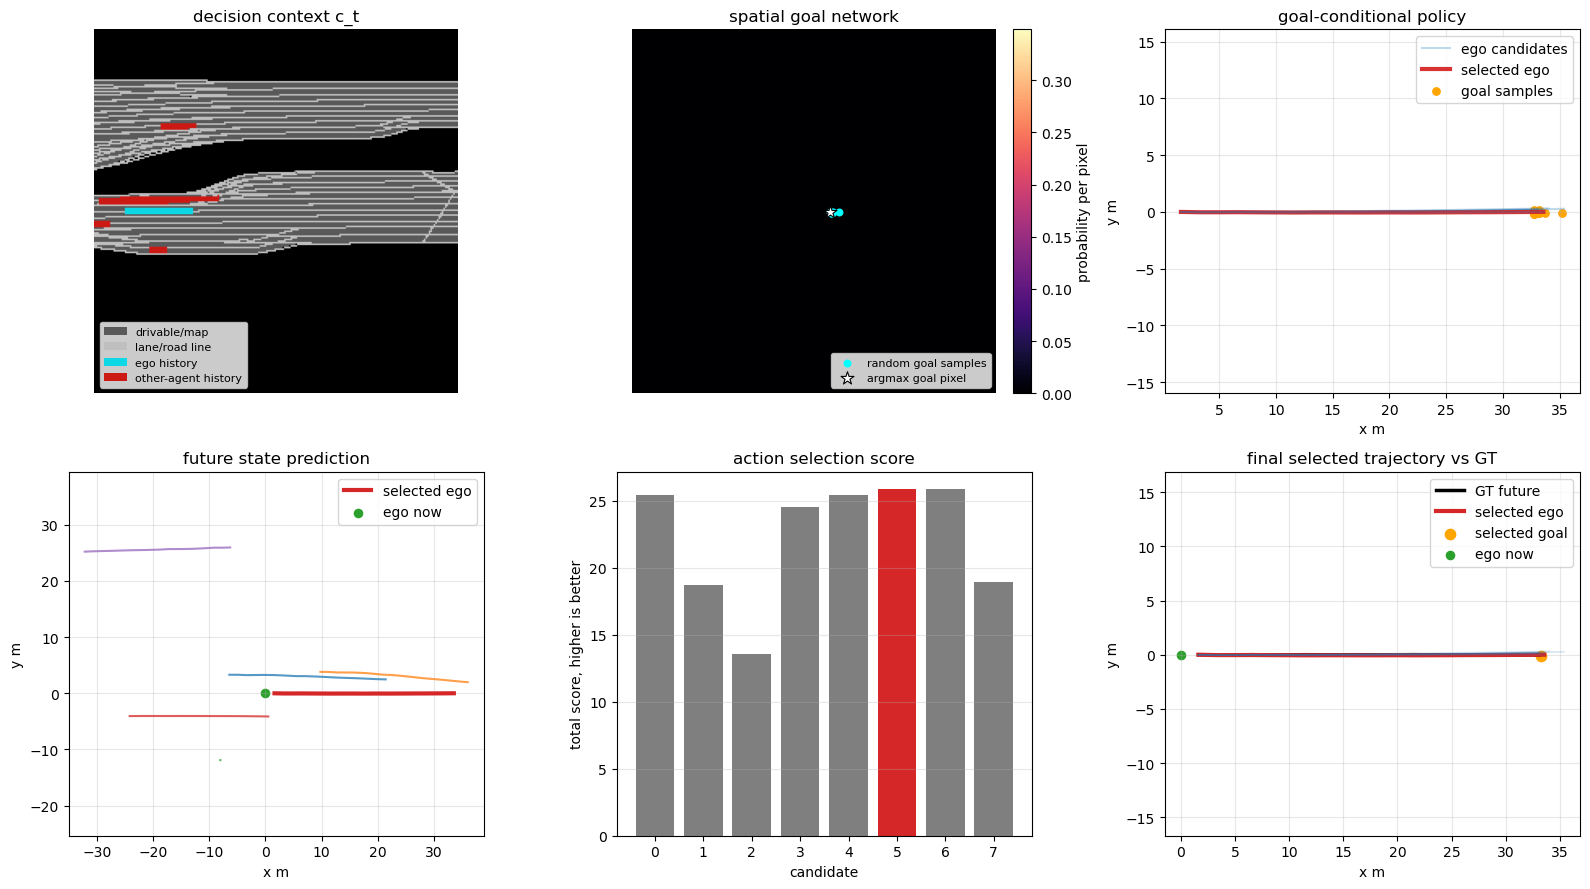

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

image = test_batch.image
history_channels = run_config.config.history_steps + 1
dynamic_channels = image[:history_channels]
ego_history_mask = np.any(dynamic_channels > 0, axis=0)
other_history_mask = np.any(dynamic_channels < 0, axis=0)
drivable = image[-3] > 0
lane_lines = image[-2] > 0
pedestrian = image[-1] > 0
preview = np.zeros((*drivable.shape, 3), dtype=float)
preview[drivable] = [0.35, 0.35, 0.35]
preview[lane_lines] = [0.75, 0.75, 0.75]
preview[pedestrian] = [0.45, 0.25, 0.55]
preview[other_history_mask] = [0.80, 0.10, 0.08]
preview[ego_history_mask] = [0.05, 0.85, 0.90]
prob_map = plan["location_prob_map"][0].detach().cpu().numpy()
argmax_row, argmax_col = np.unravel_index(np.argmax(prob_map), prob_map.shape)


def agent_to_raster(points):
    points = np.asarray(points, dtype=float)
    flat = points.reshape(-1, 2)
    hom = np.concatenate([flat, np.ones((flat.shape[0], 1))], axis=1)
    raster = hom @ test_batch.raster_from_agent.T
    return raster[:, :2].reshape(*points.shape)

raster_goal_xy = agent_to_raster(goal_xy)

available_agents = np.flatnonzero(selected_agent_availability.any(axis=1))
agent_count_to_plot = min(8, available_agents.size)
agent_indices_to_plot = available_agents[:agent_count_to_plot]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].imshow(preview)
axes[0, 0].set_title("decision context c_t")
axes[0, 0].axis("off")
axes[0, 0].legend(
    handles=[
        Patch(facecolor=(0.35, 0.35, 0.35), label="drivable/map"),
        Patch(facecolor=(0.75, 0.75, 0.75), label="lane/road line"),
        Patch(facecolor=(0.05, 0.85, 0.90), label="ego history"),
        Patch(facecolor=(0.80, 0.10, 0.08), label="other-agent history"),
    ],
    loc="lower left",
    fontsize=8,
)

im = axes[0, 1].imshow(prob_map, cmap="magma")
axes[0, 1].scatter(raster_goal_xy[:, 0], raster_goal_xy[:, 1],
                   c="cyan", s=22, label="random goal samples")
axes[0, 1].scatter([argmax_col], [argmax_row], marker="*", c="white", s=95,
                   edgecolors="black", linewidths=0.8, label="argmax goal pixel")
axes[0, 1].set_title("spatial goal network")
axes[0, 1].axis("off")
axes[0, 1].legend(loc="lower right", fontsize=8)
cbar = fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)
cbar.set_label("probability per pixel")

for index, trajectory in enumerate(ego_candidates_xy):
    alpha = 0.95 if index == selected_index else 0.28
    linewidth = 3.0 if index == selected_index else 1.5
    color = "#d62728" if index == selected_index else "#1f77b4"
    label = "selected ego" if index == selected_index else ("ego candidates" if index == 0 else None)
    axes[0, 2].plot(trajectory[:, 0], trajectory[:, 1], color=color, alpha=alpha, linewidth=linewidth, label=label)
axes[0, 2].scatter(goal_xy[:, 0], goal_xy[:, 1], color="orange", s=28, label="goal samples")
axes[0, 2].set_title("goal-conditional policy")
axes[0, 2].set_xlabel("x m")
axes[0, 2].set_ylabel("y m")
axes[0, 2].axis("equal")
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend(loc="best")

for agent_index in agent_indices_to_plot:
    agent_traj = selected_agent_xy[agent_index]
    agent_avail = selected_agent_availability[agent_index]
    axes[1, 0].plot(agent_traj[agent_avail, 0], agent_traj[agent_avail, 1], linewidth=1.5, alpha=0.75)
axes[1, 0].plot(selected_ego_xy[:, 0], selected_ego_xy[:, 1], color="#d62728", linewidth=3, label="selected ego")
axes[1, 0].scatter([0], [0], color="#2ca02c", s=35, label="ego now")
axes[1, 0].set_title("future state prediction")
axes[1, 0].set_xlabel("x m")
axes[1, 0].set_ylabel("y m")
axes[1, 0].axis("equal")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc="best")

x = np.arange(NUM_GOAL_SAMPLES)
axes[1, 1].bar(x, score_breakdown.total, color=["#d62728" if i == selected_index else "#7f7f7f" for i in x])
axes[1, 1].set_title("action selection score")
axes[1, 1].set_xlabel("candidate")
axes[1, 1].set_ylabel("total score, higher is better")
axes[1, 1].grid(True, axis="y", alpha=0.3)

axes[1, 2].plot(gt_xy[:, 0], gt_xy[:, 1], label="GT future", color="black", linewidth=2.5)
axes[1, 2].plot(selected_ego_xy[:, 0], selected_ego_xy[:, 1], label="selected ego", color="#d62728", linewidth=3)
for index, trajectory in enumerate(ego_candidates_xy):
    if index == selected_index:
        continue
    axes[1, 2].plot(trajectory[:, 0], trajectory[:, 1], color="#1f77b4", alpha=0.18, linewidth=1.2)
axes[1, 2].scatter([selected_goal_xy[0]], [selected_goal_xy[1]], label="selected goal", color="orange", s=55)
axes[1, 2].scatter([0], [0], label="ego now", color="#2ca02c", s=35)
axes[1, 2].set_title("final selected trajectory vs GT")
axes[1, 2].set_xlabel("x m")
axes[1, 2].set_ylabel("y m")
axes[1, 2].axis("equal")
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(loc="best")

plt.tight_layout()

## 6. Open-Loop Mixed Evaluation

By default this reads the saved all-mini evaluation result. Set `RUN_EVALUATION = True` in the setup cell to rerun open-loop evaluation with the selected planner and predictor checkpoints.

In [6]:
if RUN_EVALUATION:
    _model, open_loop_result = run_nuplan_bits_open_loop_protocol(
        run_config,
        OPEN_LOOP_DIR,
        tactics2d_planner_checkpoint=PLANNER_CHECKPOINT,
        predictor_checkpoint=PREDICTOR_CHECKPOINT,
        image_channels=14,
        future_steps=run_config.config.future_steps,
        hidden_dim=run_config.schedule.hidden_dim,
        model_arch=run_config.schedule.model_arch,
        context_size=run_config.schedule.context_size,
        roi_feature_size=run_config.schedule.roi_feature_size,
        roi_layer_key=run_config.schedule.roi_layer_key,
        history_conditioning=run_config.schedule.history_conditioning,
        use_transformer=run_config.schedule.use_transformer,
        strict=True,
    )
else:
    open_loop_result = None

open_loop_payload = json.loads(OPEN_LOOP_RESULT_PATH.read_text(encoding="utf-8"))
print("planner/open-loop result:", OPEN_LOOP_RESULT_PATH)
if "inference" in open_loop_payload:
    print("source:", open_loop_payload["inference"]["source"])
    print("compatible:", open_loop_payload["inference"]["compatibility"]["is_compatible"])
    for split_name in ("train", "val", "test"):
        result = open_loop_payload[split_name]
        if isinstance(result, list):
            result = result[0] if result else None
        if result is None:
            print(f"{split_name}: not evaluated in saved run")
        else:
            print(
                f"{split_name}: loss={result['mean_total_loss']:.4f}, "
                f"samples={result['sample_count']}, steps={result['step_count']}"
            )
else:
    print("source: planner-only cached eval")
    for split_name in ("train", "val", "test"):
        result = open_loop_payload.get("eval", {}).get(split_name)
        if result is None:
            print(f"{split_name}: not evaluated in saved run")
        else:
            print(
                f"{split_name}: planner_loss={result['mean_total_loss']:.4f}, "
                f"samples={result['sample_count']}, steps={result['step_count']}"
            )


planner/open-loop result: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\planner_frozen_predictor\bits_planner_cached_train_result.json
source: planner-only cached eval
train: not evaluated in saved run
val: planner_loss=0.3471, samples=8, steps=2
test: planner_loss=0.3471, samples=8, steps=2


## 7. Closed-Loop Rolling Evaluation

This optional cell can run a short rolling rollout. The default notebook execution only reports whether a saved rolling result is available.

In [7]:
if RUN_EVALUATION:
    _model, rolling_result = run_nuplan_bits_rolling_protocol(
        run_config,
        ROLLING_DIR,
        tactics2d_planner_checkpoint=PLANNER_CHECKPOINT,
        predictor_checkpoint=PREDICTOR_CHECKPOINT,
        image_channels=14,
        future_steps=run_config.config.future_steps,
        hidden_dim=run_config.schedule.hidden_dim,
        model_arch=run_config.schedule.model_arch,
        context_size=run_config.schedule.context_size,
        roi_feature_size=run_config.schedule.roi_feature_size,
        roi_layer_key=run_config.schedule.roi_layer_key,
        history_conditioning=run_config.schedule.history_conditioning,
        use_transformer=run_config.schedule.use_transformer,
        split_name="test",
        simulation_steps=1,
        parser=NuPlanParser(),
        device=DEVICE,
        map_location="cpu",
        strict=True,
        num_samples=2,
        mask_drivable=True,
    )
else:
    rolling_result = None

if ROLLING_RESULT_PATH.exists():
    rolling_payload = json.loads(ROLLING_RESULT_PATH.read_text(encoding="utf-8"))
    summary = rolling_payload["test"]["summary"]
    print("rolling result:", ROLLING_RESULT_PATH)
    print("source:", rolling_payload["inference"]["source"])
    print("compatible:", rolling_payload["inference"]["compatibility"]["is_compatible"])
    print("simulation steps:", rolling_payload["test"]["simulation_steps"])
    print("evaluated logs:", summary["evaluated_log_count"])
    print("skipped logs:", summary["skipped_log_count"])
    print("collisions:", summary["collision_count"])
    print("off-drivable:", summary["off_drivable_count"])
    print("mean off-drivable rate:", round(summary["mean_off_drivable_rate"], 4))
    print("controlled ADE:", round(summary["mean_controlled_ade"], 4))
    print("controlled FDE:", round(summary["mean_controlled_fde"], 4))
else:
    print("rolling result: not available in this notebook run")


rolling result: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\rolling_clean_decoder_eval\bits_rolling_protocol_result.json
source: mixed
compatible: True
simulation steps: 10
evaluated logs: 8
skipped logs: 0
collisions: 1
off-drivable: 105
mean off-drivable rate: 0.0774
controlled ADE: 0.0383
controlled FDE: 0.1137


## 8. Current Local Results

The saved planner checkpoint used by this inference demo is:

`D:/tactics/checkpoints/bits/nuplan_mini_all_unet_v1/train_valid57_4sample_clean_decoder_e120/planner_frozen_predictor/bits_planner_best_val.pt`

Saved run summary:

| protocol | result |
| --- | --- |
| split | train `57`, val `8`, test `8` usable logs |
| notebook mode | inference/demo only; no optimizer step is run here |
| saved training artifact | `213` cached train samples, `120` epochs, `6480` optimizer steps, final train loss `0.3854`, best/final val planner loss `0.3471` |
| training script | `scripts/run_bits_planner_cached_train.py` |
| notebook demo sample | `train[2]`, moving ego, GT displacement about `33 m`, `5` neighboring agents |
| notebook inference | `8` goal samples -> `8` ego trajectory candidates -> scorer-selected final trajectory |
| open-loop mixed | cached planner-only eval: val loss `0.3471`, test loss `0.3471`; val/test are the same eight mini logs in this local split |
| rolling mixed | not available in this notebook run |

The 64 mini logs were probed first; 57 had complete history/future windows for the saved cached setup. These numbers are a local reproduction sanity check, not a paper-level NuPlan benchmark.


## 9. Notes For The Current Architecture

The notebook now uses the current shared-encoder naming and loader path:

- planner weights: `tactics2d_planner_checkpoint=PLANNER_CHECKPOINT`;
- predictor weights: `predictor_checkpoint=PREDICTOR_CHECKPOINT`;
- high-level planner module: `planner.spatial_goal_decoder`;
- low-level heads: `predictor.policy_head` and `predictor.future_state_head`;
- full inference loader: `load_bits_inference_model`.

The demo now uses the saved local planner checkpoint trained on the 57 valid mini logs with four samples per log.